In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


In [2]:
!pip install seaborn scikit-learn
# Ruta para guardar imágenes
ruta_imagenes = r'C:\Users\diazr\Dropbox\PC\Desktop\DANI\PROYECTO\PORTFOLIO DANIEL\02 - PROYECTO HORECA PYTHON\03_Documentación\Imágenes'


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cargar dataset
df = pd.read_csv('../01_Datos/Raw/Wholesale customers data.csv')

# Primera exploración
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nPrimeras filas:")
df.head()

Filas: 440
Columnas: 8

Primeras filas:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
# Información del dataset
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== ESTADÍSTICAS BÁSICAS ===")
df.describe()

=== TIPOS DE DATOS ===
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

=== ESTADÍSTICAS BÁSICAS ===


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [5]:
# Verificar nulos y duplicados
print(f"Valores nulos:\n{df.isnull().sum()}")
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"\nValores únicos en Channel: {df['Channel'].unique()}")
print(f"Valores únicos en Region: {df['Region'].unique()}")

Valores nulos:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Filas duplicadas: 0

Valores únicos en Channel: [2 1]
Valores únicos en Region: [3 1 2]


In [6]:
# Renombrar valores para mejor legibilidad
df['Channel'] = df['Channel'].map({1: 'HORECA', 2: 'Retail'})
df['Region'] = df['Region'].map({1: 'Lisboa', 2: 'Oporto', 3: 'Otras'})

print("Valores actualizados ✓")
print(f"\nCanales: {df['Channel'].unique()}")
print(f"Regiones: {df['Region'].unique()}")

Valores actualizados ✓

Canales: ['Retail' 'HORECA']
Regiones: ['Otras' 'Lisboa' 'Oporto']


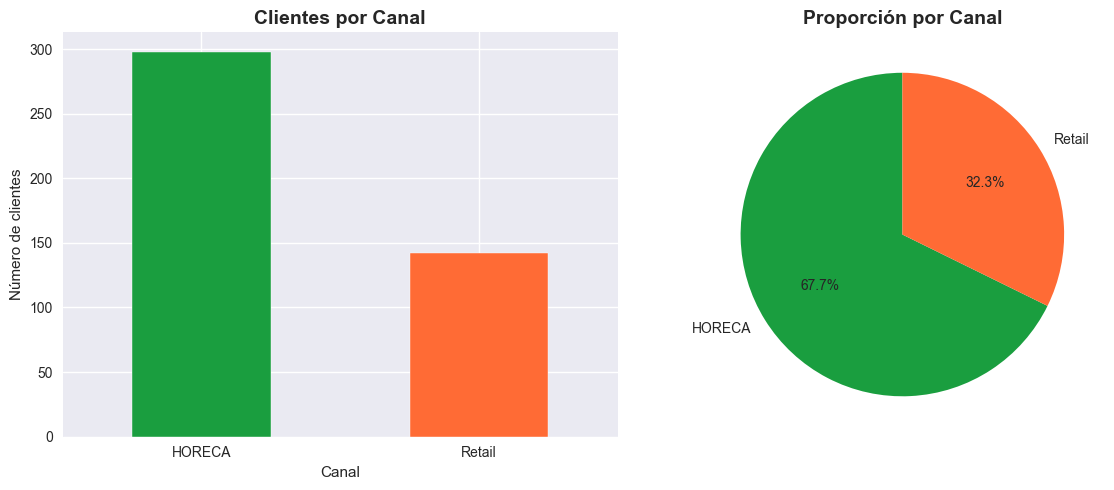

Gráfico guardado ✓


In [7]:
# Distribución de clientes por canal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
df['Channel'].value_counts().plot(kind='bar', ax=axes[0], 
                                   color=['#1a9e3f', '#ff6b35'],
                                   edgecolor='white')
axes[0].set_title('Clientes por Canal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Número de clientes')
axes[0].tick_params(rotation=0)

# Gráfico circular
df['Channel'].value_counts().plot(kind='pie', ax=axes[1],
                                   colors=['#1a9e3f', '#ff6b35'],
                                   autopct='%1.1f%%',
                                   startangle=90)
axes[1].set_title('Proporción por Canal', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}/distribucion_canal.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

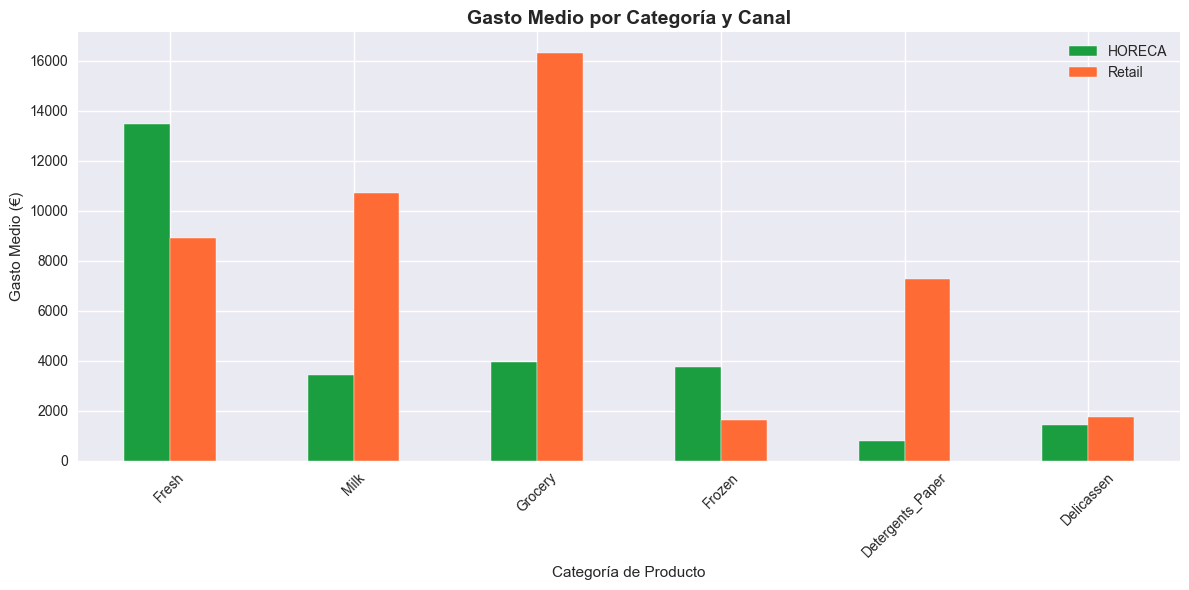

Gráfico guardado ✓


In [8]:
# Gasto medio por canal
categorias = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

gasto_medio = df.groupby('Channel')[categorias].mean()

gasto_medio.T.plot(kind='bar', figsize=(12, 6), 
                   color=['#1a9e3f', '#ff6b35'],
                   edgecolor='white')

plt.title('Gasto Medio por Categoría y Canal', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Producto')
plt.ylabel('Gasto Medio (€)')
plt.xticks(rotation=45)
plt.legend(['HORECA', 'Retail'])
plt.tight_layout()
plt.savefig(f'{ruta_imagenes}/gasto_medio_canal.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

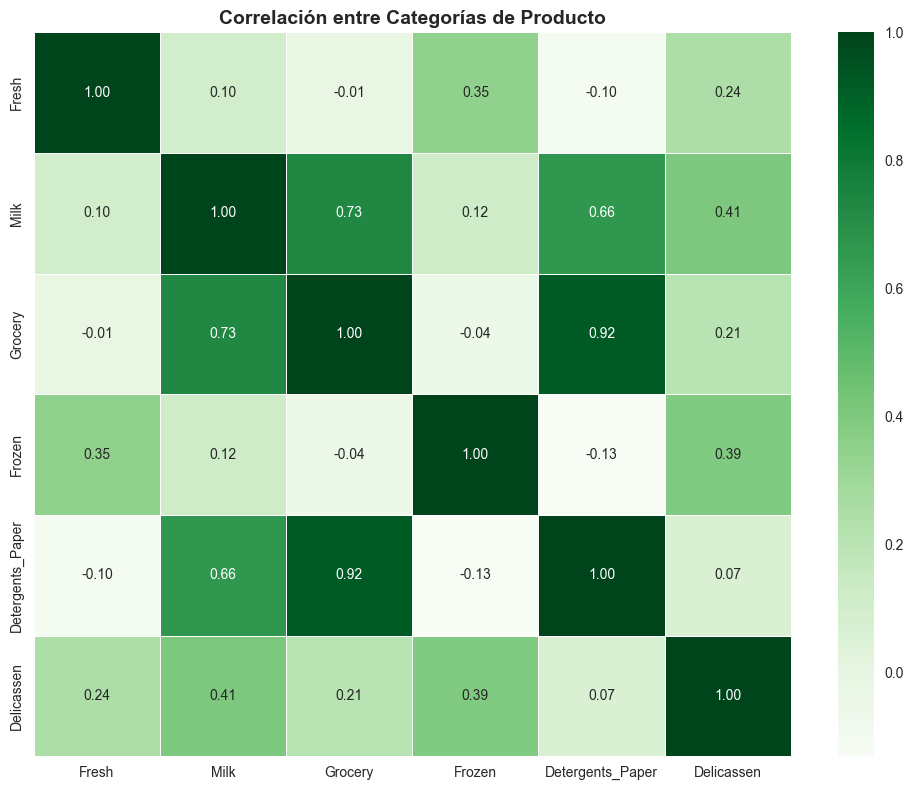

Gráfico guardado ✓


In [9]:
# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
correlaciones = df[categorias].corr()

sns.heatmap(correlaciones, 
            annot=True, 
            fmt='.2f',
            cmap='Greens',
            linewidths=0.5)

plt.title('Correlación entre Categorías de Producto', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta_imagenes}/correlaciones.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

C:\Users\diazr\AppData\Local\Temp\ipykernel_11816\2243505702.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8, color='#1a9e3f')


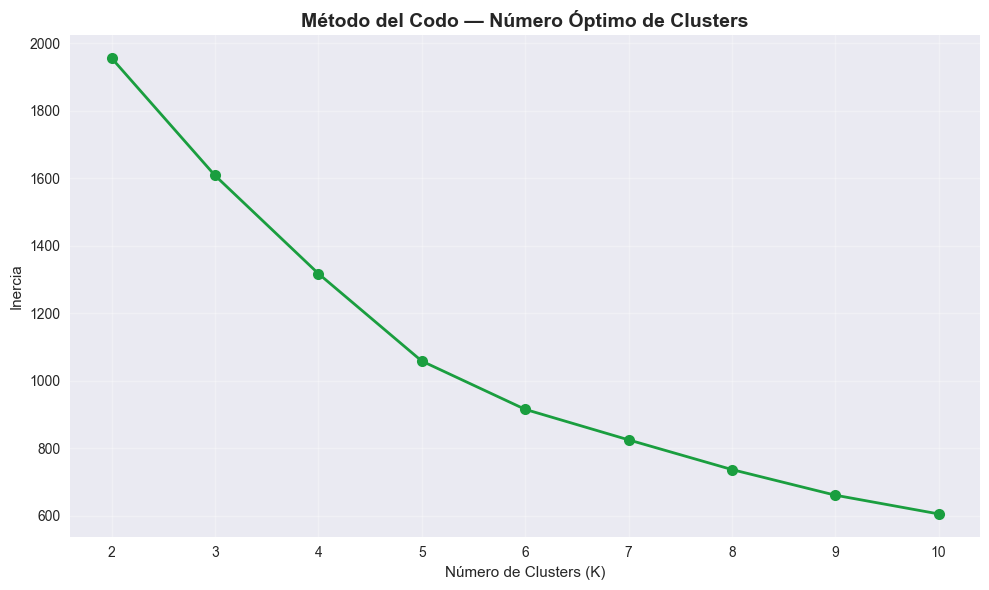

Gráfico guardado ✓


In [10]:
# Método del codo para encontrar K óptimo
X = df[categorias]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8, color='#1a9e3f')
plt.title('Método del Codo — Número Óptimo de Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ruta_imagenes}/metodo_codo.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

In [11]:
# Aplicar K-Means con K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Distribución de clientes por cluster
print("Clientes por cluster:")
print(df['Cluster'].value_counts().sort_index())

Clientes por cluster:
Cluster
0    270
1     10
2     63
3     96
4      1
Name: count, dtype: int64


In [12]:
# Perfil medio de cada cluster
perfil_clusters = df.groupby('Cluster')[categorias].mean().round(0)
print("Perfil medio por cluster:")
perfil_clusters

Perfil medio por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,9092.0,2968.0,3807.0,2272.0,990.0,979.0
1,15965.0,34708.0,48537.0,3055.0,24875.0,2943.0
2,32958.0,4997.0,5885.0,8423.0,955.0,2463.0
3,5754.0,10867.0,16607.0,1464.0,7203.0,1813.0
4,36847.0,43950.0,20170.0,36534.0,239.0,47943.0


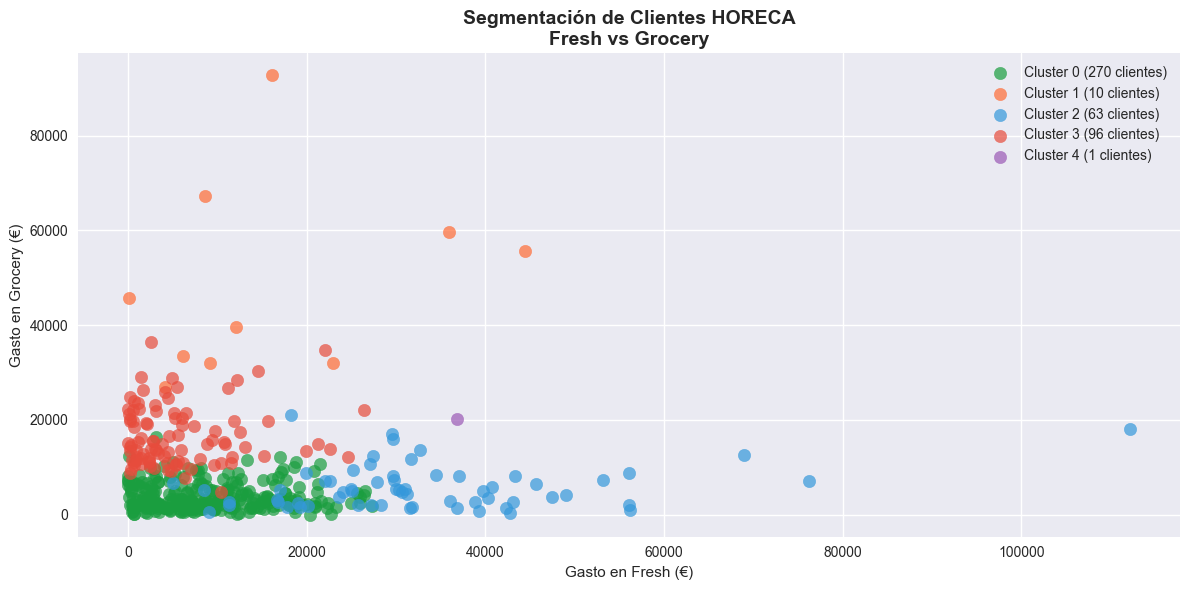

Gráfico guardado ✓


In [13]:
# Visualización de clusters
plt.figure(figsize=(12, 6))

colores = ['#1a9e3f', '#ff6b35', '#3498db', '#e74c3c', '#9b59b6']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Fresh'], 
                cluster_data['Grocery'],
                c=colores[i], 
                label=f'Cluster {i} ({len(cluster_data)} clientes)',
                alpha=0.7,
                s=80)

plt.title('Segmentación de Clientes HORECA\nFresh vs Grocery', 
          fontsize=14, fontweight='bold')
plt.xlabel('Gasto en Fresh (€)')
plt.ylabel('Gasto en Grocery (€)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{ruta_imagenes}/clusters.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")

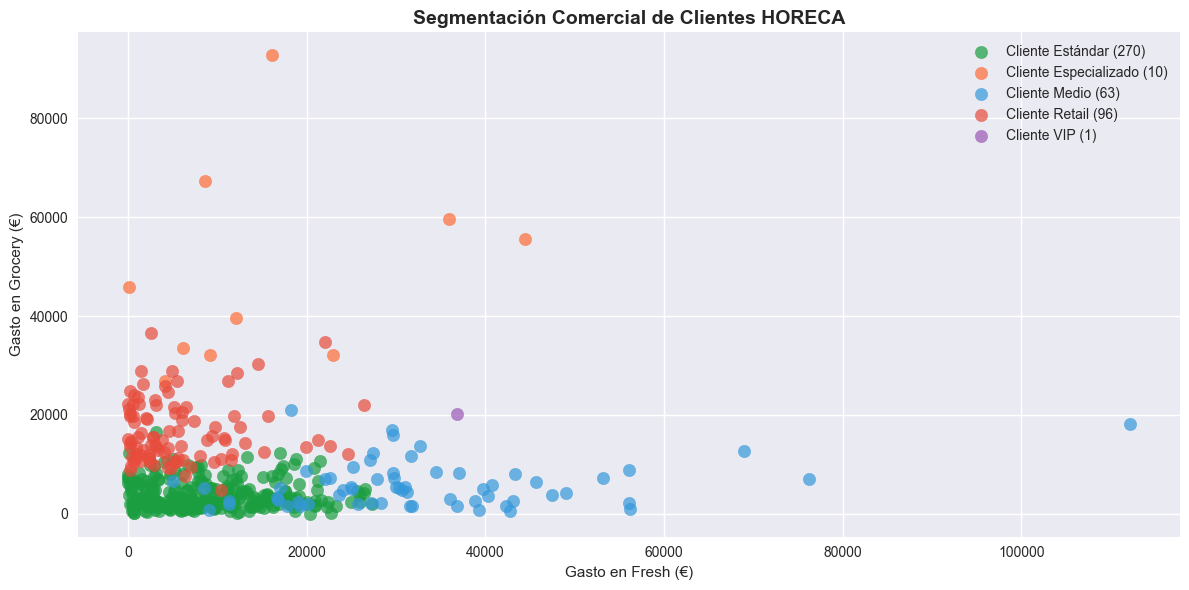

Gráfico guardado ✓


In [14]:
# Nombrar clusters con perfil comercial
nombres_clusters = {
    0: 'Cliente Estándar',
    1: 'Cliente Especializado',
    2: 'Cliente Medio',
    3: 'Cliente Retail',
    4: 'Cliente VIP'
}

df['Segmento'] = df['Cluster'].map(nombres_clusters)

# Gráfico final con nombres
plt.figure(figsize=(12, 6))

colores = ['#1a9e3f', '#ff6b35', '#3498db', '#e74c3c', '#9b59b6']

for i, (cluster, nombre) in enumerate(nombres_clusters.items()):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Fresh'], 
                cluster_data['Grocery'],
                c=colores[i], 
                label=f'{nombre} ({len(cluster_data)})',
                alpha=0.7,
                s=80)

plt.title('Segmentación Comercial de Clientes HORECA', 
          fontsize=14, fontweight='bold')
plt.xlabel('Gasto en Fresh (€)')
plt.ylabel('Gasto en Grocery (€)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{ruta_imagenes}/segmentacion_comercial.png', dpi=150)
plt.show()
print("Gráfico guardado ✓")